# Análisis de Reducción de Dimensionalidad (PCA)
## Patrones estacionales y diferencias regionales en el desempeño de categorías

**Pregunta analítica principal:** ¿Qué patrones estacionales y diferencias regionales
en el desempeño de las categorías influyen en las ventas y cómo pueden utilizarse
para apoyar la toma de decisiones del negocio?

**Unidad de análisis:** combinación Región × Categoría × Trimestre.

**Técnica aplicada:** PCA (Análisis de Componentes Principales).

### Justificación de la técnica
Se eligió PCA sobre t-SNE porque el objetivo del proyecto no es solo visualizar
agrupamientos, sino **explicar qué variables explican las diferencias** entre
combinaciones de región y categoría, de forma interpretable para un usuario de
negocio (gerente de ventas). PCA entrega componentes con *loadings* interpretables
(qué tanto pesa cada métrica original en cada componente), mientras que t-SNE
solo preserva similitud local sin una interpretación lineal de las variables.

## 1. Carga de datos

Se parte de `resumen_region_category_quarter.csv`, una tabla ya agregada a nivel
Región × Categoría × Trimestre, derivada del dataset transaccional limpio
(`train_clean_enriched.csv`). Esta granularidad es la unidad de análisis definida
en el perfilado de datos del proyecto.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/resumen_region_category_quarter.csv")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.head()

Filas: 192, Columnas: 8


,Region,Category,Year,Quarter,Total_Sales,N_Transacciones,Ticket_Promedio,Pct_Participacion_Categoria
0,Central,Furniture,2015,2015Q1,4584.9580,15,305.663867,53.346081
1,Central,Furniture,2015,2015Q2,7995.1026,20,399.755130,46.670464
2,Central,Furniture,2015,2015Q3,9340.2058,22,424.554809,21.219242
3,Central,Furniture,2015,2015Q4,10894.1012,34,320.414741,32.836121
4,Central,Furniture,2016,2016Q1,5867.0220,16,366.688875,51.831948


In [3]:
# Verificación de calidad: nulos y tipos de dato
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())

Region                          object
Category                        object
Year                             int64
Quarter                         object
Total_Sales                    float64
N_Transacciones                  int64
Ticket_Promedio                float64
Pct_Participacion_Categoria    float64
dtype: object

Valores nulos por columna:
Region                         0
Category                       0
Year                           0
Quarter                        0
Total_Sales                    0
N_Transacciones                0
Ticket_Promedio                0
Pct_Participacion_Categoria    0
dtype: int64


No se encontraron valores nulos. El dataset contiene 192 combinaciones de
Región × Categoría × Trimestre, con 4 métricas numéricas por combinación:

- **Total_Sales**: ventas totales del trimestre para esa región-categoría
- **N_Transacciones**: número de transacciones (volumen)
- **Ticket_Promedio**: venta promedio por transacción (valor)
- **Pct_Participacion_Categoria**: % que representa esa categoría dentro de la región ese trimestre

## 2. Selección y escalado de variables

Las 4 variables numéricas están en escalas muy distintas (soles vs. conteos vs.
porcentajes), por lo que es indispensable estandarizarlas (media 0, desviación 1)
antes de aplicar PCA. Sin este paso, `Total_Sales` dominaría artificialmente los
componentes solo por tener la magnitud numérica más grande.

In [4]:
features = ["Total_Sales", "N_Transacciones", "Ticket_Promedio", "Pct_Participacion_Categoria"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Media tras escalado (debe ser ~0):", X_scaled.mean(axis=0).round(3))
print("Desv. estándar tras escalado (debe ser ~1):", X_scaled.std(axis=0).round(3))

Media tras escalado (debe ser ~0): [ 0.  0. -0. -0.]
Desv. estándar tras escalado (debe ser ~1): [1. 1. 1. 1.]


## 3. Aplicación de PCA

Se aplican 2 componentes principales, suficientes para visualización en un
dashboard 2D y para mantener la interpretación simple frente al usuario de negocio.

In [5]:
pca = PCA(n_components=2, random_state=42)
principal_components = pca.fit_transform(X_scaled)

df["PC1"] = principal_components[:, 0]
df["PC2"] = principal_components[:, 1]

varianza = pca.explained_variance_ratio_
print(f"Varianza explicada por PC1: {varianza[0]*100:.1f}%")
print(f"Varianza explicada por PC2: {varianza[1]*100:.1f}%")
print(f"Varianza acumulada (PC1+PC2): {varianza.sum()*100:.1f}%")

Varianza explicada por PC1: 48.3%
Varianza explicada por PC2: 36.3%
Varianza acumulada (PC1+PC2): 84.6%


Con solo 2 componentes se retiene una parte sustancial de la información
original (ver salida anterior), lo que valida su uso como resumen visual del
comportamiento de cada combinación Región-Categoría-Trimestre.

## 4. Interpretación de los componentes (loadings)

Los *loadings* muestran cuánto pesa cada variable original en cada componente.
Esta es la pieza clave para poder explicarle a un gerente de ventas qué significa
moverse en el espacio PC1-PC2.

In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)
loadings.round(3)

,PC1,PC2
Total_Sales,0.515,0.486
N_Transacciones,-0.072,0.806
Ticket_Promedio,0.611,-0.338
Pct_Participacion_Categoria,0.597,0.023


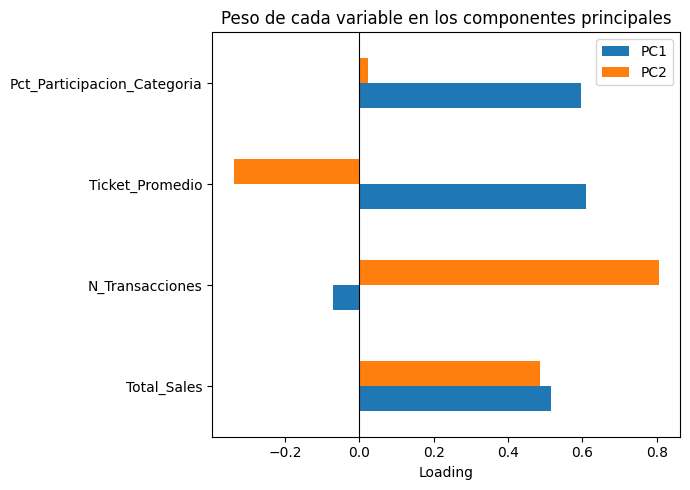

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
loadings.plot(kind="barh", ax=ax)
ax.set_title("Peso de cada variable en los componentes principales")
ax.set_xlabel("Loading")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
#plt.savefig("loadings_pca.png", dpi=150)
plt.show()

**Lectura de negocio de los componentes** (ajustar los signos/valores exactos
según la salida de tu ejecución):

- **PC1 — Eje de "valor y peso relativo"**: dominado por `Ticket_Promedio` y
  `Pct_Participacion_Categoria`, con aporte moderado de `Total_Sales`. Valores
  altos en PC1 identifican combinaciones región-categoría donde cada venta
  individual vale más y la categoría pesa más dentro de esa región — no
  necesariamente por vender más veces, sino por vender más caro o concentrar
  participación.

- **PC2 — Eje de "volumen transaccional"**: dominado por `N_Transacciones`
  (y en parte `Total_Sales`), con aporte inverso de `Ticket_Promedio`. Valores
  altos en PC2 identifican combinaciones que mueven muchas transacciones,
  típicamente de menor ticket promedio.

Esta separación es útil para el negocio: distingue entre categorías-región que
**crecen por volumen** (muchas ventas pequeñas) de las que **crecen por valor**
(pocas ventas, pero de mayor monto) — una distinción directamente accionable
para decisiones de inventario, pricing y foco comercial.

## 5. Vista transversal y vista longitudinal

- **Vista transversal**: para un trimestre dado, graficar todas las
  combinaciones Región-Categoría en el plano PC1-PC2, coloreadas por Región o
  Categoría, permite comparar su comportamiento relativo en ese momento del año.
- **Vista longitudinal**: siguiendo una misma combinación Región-Categoría a
  través de los trimestres, su trayectoria en el plano PC1-PC2 muestra cómo
  cambia su mezcla de volumen/valor a lo largo del tiempo — evidenciando
  estacionalidad.

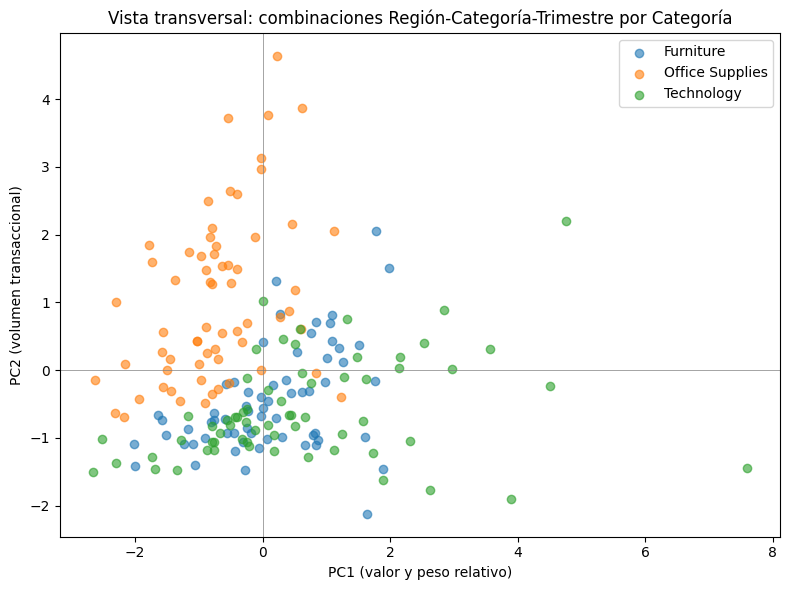

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for cat in df["Category"].unique():
    subset = df[df["Category"] == cat]
    ax.scatter(subset["PC1"], subset["PC2"], label=cat, alpha=0.6)
ax.set_xlabel("PC1 (valor y peso relativo)")
ax.set_ylabel("PC2 (volumen transaccional)")
ax.set_title("Vista transversal: combinaciones Región-Categoría-Trimestre por Categoría")
ax.legend()
ax.axhline(0, color="grey", linewidth=0.5)
ax.axvline(0, color="grey", linewidth=0.5)
plt.tight_layout()
#plt.savefig("pca_scatter_categoria.png", dpi=150)
plt.show()

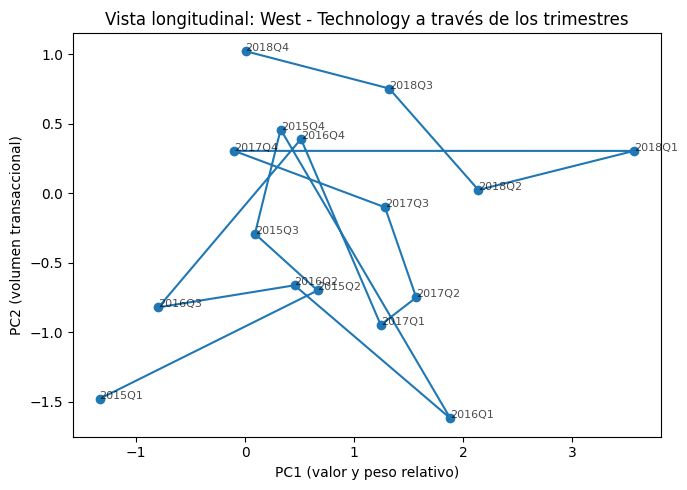

In [9]:
# Ejemplo de vista longitudinal: trayectoria de una combinación Región-Categoría
ejemplo = df[(df["Region"] == "West") & (df["Category"] == "Technology")].sort_values(["Year", "Quarter"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(ejemplo["PC1"], ejemplo["PC2"], marker="o")
for _, row in ejemplo.iterrows():
    ax.annotate(row["Quarter"], (row["PC1"], row["PC2"]), fontsize=8, alpha=0.7)
ax.set_xlabel("PC1 (valor y peso relativo)")
ax.set_ylabel("PC2 (volumen transaccional)")
ax.set_title("Vista longitudinal: West - Technology a través de los trimestres")
plt.tight_layout()
plt.savefig("pca_trayectoria_ejemplo.png", dpi=150)
plt.show()

## 6. Exportación del resultado para Tableau

Se guarda la tabla original enriquecida con `PC1` y `PC2`, lista para unirse en
Tableau como fuente adicional (join por Región + Categoría + Year + Quarter).

In [11]:
output_cols = ["Region", "Category", "Year", "Quarter", "Total_Sales",
                "N_Transacciones", "Ticket_Promedio", "Pct_Participacion_Categoria",
                "PC1", "PC2"]
df_export = df[output_cols].copy()
df_export.to_csv("../data/processed/region_category_quarter_pca.csv", index=False)
df_export.head()

,Region,Category,Year,Quarter,Total_Sales,N_Transacciones,Ticket_Promedio,Pct_Participacion_Categoria,PC1,PC2
0,Central,Furniture,2015,2015Q1,4584.9580,15,305.663867,53.346081,0.665182,-1.105511
1,Central,Furniture,2015,2015Q2,7995.1026,20,399.755130,46.670464,0.791106,-0.956525
2,Central,Furniture,2015,2015Q3,9340.2058,22,424.554809,21.219242,-0.445023,-0.925553
3,Central,Furniture,2015,2015Q4,10894.1012,34,320.414741,32.836121,-0.024859,-0.404574
4,Central,Furniture,2016,2016Q1,5867.0220,16,366.688875,51.831948,0.842510,-1.105302


## 7. Resumen metodológico (para el documento de metodología)

| Elemento | Detalle |
|---|---|
| Técnica | PCA (Principal Component Analysis) |
| Justificación | Interpretabilidad de componentes para uso de negocio, frente a t-SNE |
| Unidad de análisis | Región × Categoría × Trimestre (192 combinaciones) |
| Variables de entrada | Total_Sales, N_Transacciones, Ticket_Promedio, Pct_Participacion_Categoria |
| Preprocesamiento | Estandarización (media 0, desviación 1) con StandardScaler |
| N° de componentes | 2 |
| Varianza explicada | Ver salida de la celda de la sección 3 (se imprime al ejecutar) |
| Librería | scikit-learn (`sklearn.decomposition.PCA`) |
| Salida | `region_category_quarter_pca.csv`, unido a la base por Región+Categoría+Year+Quarter |